# Using the Detector class

Welcome to the Demo notebook, in this notebook we will go over the functions of the detector class and how to use it.  
After installing the repository using `pip` as stated in the [installation guide](../INSTALL.md) you can start this notebook


In [2]:
# start by importing the necessary packages
import cv2
import os
import matplotlib.pyplot as plt
cwd = os.getcwd()
print(f"Current dir: {cwd}")
demo_fldr = os.path.join("C:\\","Users","Queen's University",'2DMatGmm','demo')
os.chdir(demo_fldr)
from demo_functions import visualise_flakes, remove_vignette
os.chdir(cwd)
import json
import threading
import time

# import the detector
from GMMDetector import MaterialDetector

IMAGE_DIR = "img_folder"

Current dir: C:\Users\Queen's University\Desktop\Detector


## Defining the parameters

The parameters of the model can either be read directly from a `.json` file or be defined in the code itself, as shown below.  
The parameters always need to following keys:

| Key               | Description                                                        |
| ----------------- | ------------------------------------------------------------------ |
| `contrast`          | The mean contrast of the layer to be detected                      |
| `covariance_matrix` | The standard deviation of the contrast of the layer to be detected |

The defined paramters are the parameters from the `GMMDetector/trained_parameters/Graphene_GMM.json` and thus usable for graphene on 90nm SiO2.


In [3]:
# load the contrast_dict from a json file
contrast_dict = json.load(open(os.path.join("C:\\","Users","Queen's University","Desktop","Detector","trained_parameters","MoS2_test2_no_flatfield.json"),"r"))

## Instantiate the model

The model takes a few different parameters, these are described in the following table:

| Parameter                      | Description                                                                                                          |
| ------------------------------ | -------------------------------------------------------------------------------------------------------------------- |
| `contrast_dict`                | The contrast dictionary of the material, Keys are the layer names, values are the contrast and the covariance matrix |
| `size_threshold`               | The minimal size of a flake in pixels.                                                                               |
| `standard_deviation_threshold` | The maximal standard deviation threshold for the GMM of the contrast in a flake.                                     |
| `used_channels`                | The used channels for the detection, this is "BGR" by default for all channels                                       |
| `false_positive_detector_path` | The path to the false positive detector model.                                                                       |


In [4]:
model = MaterialDetector(
    contrast_dict=contrast_dict,
    size_threshold=500,
    standard_deviation_threshold=5,
    used_channels="BGR",
)

## Start Detecting flakes

The model expects an image in the BGR format and __without__ Vignetting, the Demo images have their vigenetting removed.  
If you want to use your own images, make sure to remove the vignetting first by recording a flatfield image and calling the `remove_vigentte` function. 
   
When reading image using OpenCV, the image is read in BGR format.  
If you are using any other library to read the image, make sure to convert it to BGR format before passing it to the model.

The Model returns a list of `Flakes`, the `Flakes` are saved in a class called [Flake](../GMMDetector/structures/FlakeClass.py).
This `Flake` class has the following attributes:

| Attribute                    | Description                                                                                        |
| ---------------------------- | -------------------------------------------------------------------------------------------------- |
| `mask`                       | The mask of the flake, a 2D array with 1s and 0s indicating the flake and background respectively. |
| `thickness`                  | The name of the layer the flake is from.                                                           |
| `size`                       | The size of the flake in pixels.                                                                   |
| `mean_contrast`              | The mean contrast of the flake in BGR as defined in "https://arxiv.org/abs/2306.14845".            |
| `center`                     | The center of the flake in pixels relative to the top left corner of the image.                    |
| `max_sidelength`             | The maximum sidelength of the flake in pixels, measured using a rotated bounding box.              |
| `min_sidelength`             | The minimum sidelength of the flake in pixels, measured using a rotated bounding box.              |
| `false_positive_probability` | The probability of the flake being a false positive. This is the same a $1 - \text{Confidence}$                                               |
| `entropy`                    | The Shannon entropy of the flake.                                                                  |


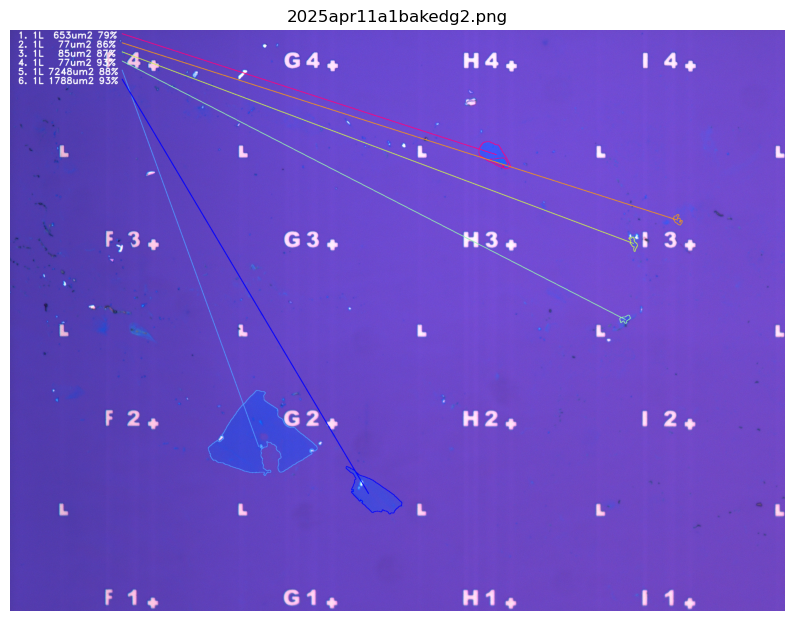

Press ENTER to stop...
 


Stopped.


In [7]:
# Set the confidence threshold to 0 to see all the flakes
CONFIDENCE_THRESHOLD = 0.5

# read the flatfield image if necessary
# flatfield = cv2.imread("flatfield.png")

valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.TIF', '.TIFF')
image_names = os.listdir(IMAGE_DIR)

output_dir = os.path.join("C:\\","Users","Queen's University","Desktop","Detector","output")

try:
    os.mkdir(output_dir)
except FileExistsError:
    print("Rename your old output folder and make a new one for this new set!")
else:
    
    processed_files = set()
    stop_flag = False
    
    def watch_folder():
        global stop_flag
    
        while not stop_flag:
            image_names = os.listdir(IMAGE_DIR)
    
            for image_name in image_names:
                if not image_name.lower().endswith(valid_ext):
                    continue
    
                if image_name in processed_files:
                    continue
    
                image_path = os.path.join(IMAGE_DIR, image_name)
                image = cv2.imread(image_path)
    
                if image is None:
                    print(f"Failed to load: {image_path}")
                    continue
    
                flakes = model.detect_flakes(image)
    
                image_out = visualise_flakes(
                    flakes,
                    image,
                    confidence_threshold=CONFIDENCE_THRESHOLD,
                )
                
                # added code to save images
                output_path = os.path.join(output_dir, image_name)
                cv2.imwrite(output_path, image_out)
    
                plt.figure(figsize=(10, 10))
                plt.imshow(image_out[:, :, ::-1])
                plt.axis("off")
                plt.title(image_name)
                plt.show()
    
                processed_files.add(image_name)
    
            time.sleep(2)  # check every 2 seconds
    
    
    # Run watcher in background thread
    thread = threading.Thread(target=watch_folder)
    thread.start()
    
    # Wait for user to stop
    input("Press ENTER to stop...\n")
    stop_flag = True
    thread.join()
    
    print("Stopped.")